# Régression du prix — français d'occasion (french-second-hand-cars)

Notebook **end-to-end** en deux temps :
1. **Régression linéaire simple** (`LinearRegression`) — on la fait une première fois, sans fioritures, pour avoir un repère.
2. **Ridge / Lasso** — versions « régularisées » de la même régression, pour comparer et stabiliser.

**Rappel des métriques** (toutes = « à quel point on se trompe ») :
- **MAE** = erreur moyenne en euros (intuitive).
- **RMSE** = erreur en euros, mais **punit fort les gros ratés** (si RMSE ≫ MAE → quelques grosses erreurs).
- **R²** = part des variations de prix expliquée (0 = nul, 1 = parfait).

> On reste sur du **linéaire** (interprétable, aligné BC04). Code partagé dans `ml/src/features.py`, données brutes jamais modifiées.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import clean_cars, load_premium_table, add_brand_features

RAW = "../../data/french-second-hand-cars/raw/French_second_hand_cars.csv"
REF = "../../references/premium_brand.csv" 

## 🟦 1. PRÉPROCESSING — nettoyage + features

`clean_cars` retire les électriques purs, parse les colonnes sales et dérive
`boite_auto`, `garantie_constructeur`, `garantie_mois`. `add_brand_features`
extrait la marque (multi-mots gérés) et son `niveau` premium (0/1/2).

In [2]:
df = clean_cars(RAW)
ref = load_premium_table(REF)
df = add_brand_features(df, ref)

# sauvegarde du nettoyé (raw jamais modifié)
PROC = Path("../../data/french-second-hand-cars/processed")
PROC.mkdir(parents=True, exist_ok=True)
df.to_csv(PROC / "cars_clean.csv", index=False)

print("shape:", df.shape, "| marques non reconnues:", df["marque"].isna().sum())
df[["carmodel","marque","palier","niveau","boite_auto","garantie_constructeur","garantie_mois"]].head(3)

shape: (2340, 50) | marques non reconnues: 0


,carmodel,marque,palier,niveau,boite_auto,garantie_constructeur,garantie_mois
0,\n RENAULT TWINGO 3\n,RENAULT,generaliste,0,0,0,12.0
1,\n BMW SERIE 4 F36 GRAN COUPE\n,BMW,premium,1,1,0,24.0
2,\n BMW SERIE 2 F45 ACTIVE TOURER\n,BMW,premium,1,1,0,6.0


## 🟦 2. PRÉPROCESSING — features (X), cible (y), split train/test

- **X** = les features (ce qu'on donne au modèle), **y** = le prix (cible).
- Split **80 % train / 20 % test**, `random_state=42` pour la reproductibilité.

In [3]:
features = ["annee", "kilometrage", "puissance_din", "puissance_fisc",
            "nombredeportes", "nombredeplaces",
            "niveau", "boite_auto", "garantie_constructeur", "garantie_mois"]

data = df[features + ["price"]].dropna(subset=["price"])   # on ne drop que la cible
X, y = data[features], data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (1872, 10) | test: (468, 10)


# Temps 1 — Régression linéaire simple

On commence par le modèle le plus direct : `LinearRegression`.

Petit détail : `garantie_mois` a des trous (NA), or la régression n'accepte pas de valeurs vides.
On les **remplit par la médiane du train** (jamais du test → pas de fuite).

## 🟩 3. ENTRAÎNEMENT

In [4]:
# remplir les NA avec la médiane calculée SUR LE TRAIN
med = X_train.median()
X_train_f = X_train.fillna(med)
X_test_f  = X_test.fillna(med)

lin = LinearRegression()
lin.fit(X_train_f, y_train)   # apprentissage
print("modèle entraîné sur", len(X_train_f), "voitures")

modèle entraîné sur 1872 voitures


## 🟥 4. ÉVALUATION

In [5]:
y_pred = lin.predict(X_test_f)

mae_lin  = mean_absolute_error(y_test, y_pred)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lin   = r2_score(y_test, y_pred)

print(f"MAE  : {mae_lin:,.0f} €")
print(f"RMSE : {rmse_lin:,.0f} €")
print(f"R²   : {r2_lin:.3f}")

MAE  : 8,742 €
RMSE : 15,813 €
R²   : 0.727


# Temps 2 — Ridge & Lasso (régularisation)

**Le problème du linéaire simple** : ses coefficients peuvent s'emballer (surtout quand des
features se ressemblent, ex. puissance din / fiscale). Il « colle » trop au train → risque
d'**overfitting**.

**Ridge et Lasso** = la même régression, mais avec une **pénalité** qui empêche les coefficients
de devenir trop gros. Cette pénalité a une force réglable : l'hyperparamètre **`alpha`**.
- **Ridge** : réduit tous les coefficients (les rapproche de 0 sans les annuler).
- **Lasso** : peut mettre des coefficients **à 0** → fait une sélection de features.

Deux prérequis :
- **StandardScaler** (mettre les features à la même échelle) : obligatoire, sinon la pénalité
  frappe injustement les features à grandes unités (kilométrage) vs petites (nb portes).
- **GridSearchCV** : teste plusieurs `alpha` en validation croisée et garde le meilleur.
Le tout dans un **pipeline** (scaler + modèle) → fit sur le train seul, pas de fuite.

## 🟩🟥 5. Entraînement + évaluation Ridge / Lasso

In [6]:
def pipe(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

def cherche_alpha(model, grille, nom):
    grid = GridSearchCV(pipe(model), {"model__alpha": grille},
                        cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid.fit(X_train_f, y_train)
    pred = grid.predict(X_test_f)
    return {
        "modèle": nom,
        "meilleur alpha": grid.best_params_["model__alpha"],
        "MAE (€)":  round(mean_absolute_error(y_test, pred)),
        "RMSE (€)": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R²":       round(r2_score(y_test, pred), 3),
    }, grid.best_estimator_

res_ridge, best_ridge = cherche_alpha(Ridge(max_iter=10000), [0.01,0.1,1,10,100,1000], "Ridge")
res_lasso, best_lasso = cherche_alpha(Lasso(max_iter=10000), [0.1,1,10,100,500,1000], "Lasso")

## 📊 6. Comparaison des 3 modèles

In [7]:
comparaison = pd.DataFrame([
    {"modèle": "LinearRegression", "meilleur alpha": "—",
     "MAE (€)": round(mae_lin), "RMSE (€)": round(rmse_lin), "R²": round(r2_lin,3)},
    res_ridge,
    res_lasso,
])
comparaison

,modèle,meilleur alpha,MAE (€),RMSE (€),R²
0,LinearRegression,—,8742,15813,0.727
1,Ridge,1000,8205,16283,0.711
2,Lasso,1000,8298,15726,0.730


## 🟥 7. Coefficients — que retient chaque modèle ?

Sur features standardisées, un coefficient = effet en € d'**un écart-type** de la feature
(donc comparables entre eux). Regarde si **Lasso** met des features à 0.

In [8]:
coefs = pd.DataFrame({
    "feature": features,
    "LinearRegression": lin.coef_ * X_train_f.std().values,  # ramené à l'échelle std pour comparer
    "Ridge": best_ridge.named_steps["model"].coef_,
    "Lasso": best_lasso.named_steps["model"].coef_,
}).round(0).sort_values("Ridge", key=abs, ascending=False)
coefs

,feature,LinearRegression,Ridge,Lasso
3,puissance_fisc,10694.0,7508.0,9879.0
2,puissance_din,8801.0,7398.0,9369.0
6,niveau,6624.0,5008.0,5773.0
1,kilometrage,-4409.0,-3413.0,-4622.0
0,annee,5330.0,2831.0,3822.0
7,boite_auto,531.0,2085.0,184.0
4,nombredeportes,-1466.0,-1600.0,-0.0
8,garantie_constructeur,1038.0,1090.0,284.0
9,garantie_mois,224.0,781.0,0.0
5,nombredeplaces,226.0,-364.0,-0.0


## 🟥 8. Réel vs prédit (Ridge)

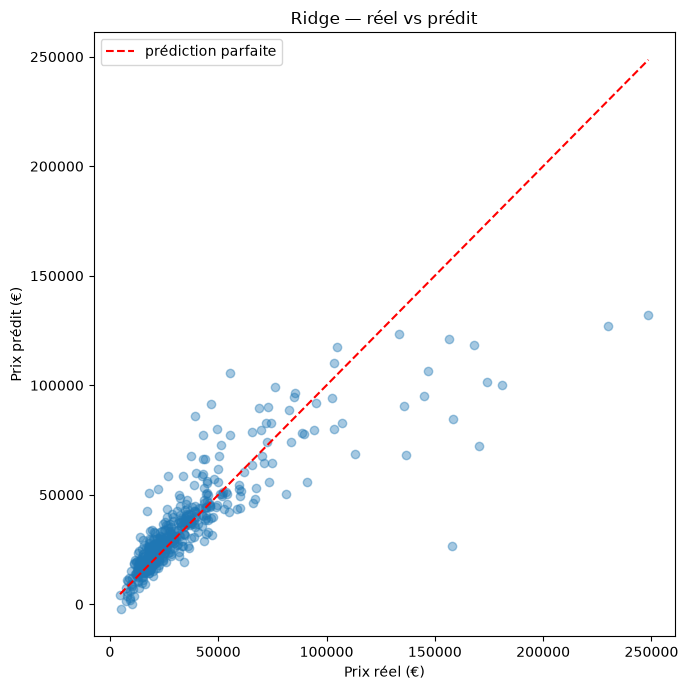

In [9]:
pred = best_ridge.predict(X_test_f)
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="prédiction parfaite")
plt.xlabel("Prix réel (€)"); plt.ylabel("Prix prédit (€)")
plt.title("Ridge — réel vs prédit"); plt.legend()
plt.tight_layout(); plt.show()

## Lecture

- **Temps 1 (LinearRegression)** = repère simple et lisible.
- **Temps 2 (Ridge/Lasso)** : la régularisation stabilise les coefficients (compromis **biais↑ / variance↓**)
  et, ici, réglée pour minimiser le **MAE** (l'erreur typique).
- **Lasso** met des coefficients à 0 → il te dit quelles features comptent vraiment.
- Limite persistante : le linéaire modélise mal la **dépréciation non linéaire** (piste future : modèle à arbres).
- Toujours pas de **fourchette + incertitude** (prochaine exigence produit).